In [5]:
# ====================================================================
# TRAINING: Joint Regression Model for Parameter Prediction
# ====================================================================
# Predicts: mixing ratio, logA (both sides), and n (for applicable models)
# Uses: CNN feature extractor + dual MLP heads for left/right components

import numpy as np
import pandas as pd
import pickle

In [4]:
#!pip install --upgrade tensorflow

In [ ]:
# ====================================================================
# LOAD TRAINING DATA
# ====================================================================

with open("/kaggle/input/curves-data-generation-a/data_classification.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
y_train = data["y_train"]
y_left_train = data["y_left_train"]
y_right_train = data["y_right_train"]
X_val = data["X_val"]
y_val = data["y_val"]
y_left_val = data["y_left_val"]
y_right_val = data["y_right_val"]
X_test = data["X_test"]
y_test = data["y_test"]
y_left_test = data["y_left_test"]
y_right_test = data["y_right_test"]
p = data["p"]
q = data["q"]
r = data["r"]
params = data["params"]
BATCH_SIZE = data["BATCH_SIZE"]
STEPS_PER_EPOCH = data["STEPS_PER_EPOCH"]
VALIDATION_STEPS = data["VALIDATION_STEPS"]
TEST_STEPS = data["TEST_STEPS"]
SEGMENTS = data["SEGMENTS"]
EPOCHS = data["EPOCHS"]

In [ ]:
# ====================================================================
# PREPROCESS TG SPECTRA
# ====================================================================
# Build derivative channels after loading clean TG spectra.

DERIVATIVE_MODE = "all"  # "first", "first_second", or "all"
NOISE_LEVEL = 0.00  # 0.00, 0.01, 0.02, or 0.05; applied to test only
NOISE_SCALING = "per_curve_range"  # "per_curve_range", "global_range", or "absolute"
NOISE_SEED = 42

if DERIVATIVE_MODE not in {"first", "first_second", "all"}:
    raise ValueError("DERIVATIVE_MODE must be 'first', 'first_second', or 'all'")
if NOISE_LEVEL not in {0.00, 0.01, 0.02, 0.05}:
    raise ValueError("NOISE_LEVEL must be 0.00, 0.01, 0.02, or 0.05")
if NOISE_SCALING not in {"per_curve_range", "global_range", "absolute"}:
    raise ValueError("Unsupported NOISE_SCALING")

def add_noise(curves, noise_level=0.0, scaling="per_curve_range", seed=None):
    """Add zero-mean Gaussian noise to TG spectra."""
    curves = np.asarray(curves, dtype=np.float32)
    if noise_level == 0.0:
        return curves.copy()
    rng = np.random.default_rng(seed)
    if scaling == "per_curve_range":
        scale = np.ptp(curves, axis=1, keepdims=True)
    elif scaling == "global_range":
        scale = np.ptp(curves)
    elif scaling == "absolute":
        scale = 1.0
    else:
        raise ValueError("Unsupported noise scaling")
    return curves + rng.normal(0.0, noise_level * scale, size=curves.shape).astype(np.float32)

def build_features(curves, temperature, temp_step, derivative_mode="all"):
    """Convert TG spectra into the selected derivative feature channels."""
    curves = np.asarray(curves, dtype=np.float32)
    first = np.diff(curves, axis=1, prepend=curves[:, :1]) / temp_step
    if derivative_mode == "first":
        return first[..., None]
    if derivative_mode == "first_second":
        second = np.diff(first, axis=1, prepend=first[:, :1]) / temp_step
        return np.stack([first, second], axis=-1)
    if derivative_mode == "all":
        second = np.diff(first, axis=1, prepend=first[:, :1]) / temp_step
        scaled_first = first * np.asarray(temperature, dtype=np.float32)[None, :] ** 2
        return np.stack([first, second, scaled_first], axis=-1)
    raise ValueError("Unsupported derivative mode")

temperature = data["temperature"]
temp_step = data["temp_step"]
X_train = build_features(X_train, temperature, temp_step, DERIVATIVE_MODE)
X_val = build_features(X_val, temperature, temp_step, DERIVATIVE_MODE)
X_test = build_features(
    add_noise(X_test, NOISE_LEVEL, NOISE_SCALING, NOISE_SEED),
    temperature,
    temp_step,
    DERIVATIVE_MODE,
)
print(f"Features: {DERIVATIVE_MODE}, test noise: {NOISE_LEVEL:.0%} ({NOISE_SCALING})")

In [7]:
# ====================================================================
# IMPORTS AND CONFIGURATION
# ====================================================================

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, BatchNormalization, Reshape, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras import backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping

# Configuration
p = 900  # Input dimension
r = 7    # Number of models

# Hyperparameters (from Optuna optimization)
BEST_CONV_FILTERS = 64
BEST_CONV_KERNEL = 9
BEST_CONV_STRIDE = 1
BEST_DENSE_UNITS = 128
BEST_ACTIVATION = 'relu'
LEARNING_RATE = 0.0008246801692301988
BATCH_SIZE = 128
EPOCHS = 80

# Masking for n-parameter (non-n models: D2, D3, D4, R2, R3)
N_PLACEHOLDER_VALUE = -1.0
N_USING_MODELS = [3, 4]  # Fn, JMA

In [ ]:
# ====================================================================
# HELPER: CNN Feature Extractor
# ====================================================================
# Builds a shared CNN that extracts features from selected TG channels

def build_cnn_feature_extractor(input_shape, conv_filters, conv_kernel, conv_stride, activation, dense_units):
    """
    Constructs a CNN feature extractor.

    Parameters:
    -----------
    input_shape : tuple
        Shape of input, including the selected feature channels.
    conv_filters : int
        Number of 1D convolutional filters
    conv_kernel : int
        Kernel size for convolution
    conv_stride : int
        Stride for convolution
    activation : str
        Activation function (relu, selu, elu)
    dense_units : int
        Hidden dimension after flattening

    Returns:
    --------
    Model : Keras model with input curve and output features
    """
    input_tensor = Input(shape=input_shape)
    input_channels = input_shape[1] if len(input_shape) > 1 else 1
    x = Reshape((input_shape[0], input_channels))(input_tensor)
    x = Conv1D(conv_filters, conv_kernel, strides=conv_stride, activation=activation)(x)
    x = BatchNormalization()(x)
    x = Flatten()(x)
    x = Dense(dense_units, activation=activation)(x)
    x = BatchNormalization(name='feature_output')(x)
    return Model(inputs=input_tensor, outputs=x, name='cnn_feature_extractor')

In [ ]:
# ====================================================================
# MODEL CONSTRUCTION - Joint Regression with Dual Output Heads
# ====================================================================
# Key insight: n-heads need DIRECT access to curve features
# Shared features are biased by non-n samples, so they don't encode n-variation
#
# Solution:
# - A-heads use shared features (good for A, which all models use)
# - N-heads get INTERMEDIATE CNN outputs (before averaging across all samples)
# - This gives n-heads access to curve signals independent of class averaging

def build_cnn_with_intermediate_output(input_shape, conv_filters, conv_kernel, conv_stride, activation, dense_units):
    """
    Builds CNN that returns BOTH final features and intermediate features.
    Intermediate features (after first dense) encode curve-specific information.
    """
    input_tensor = Input(shape=input_shape)
    input_channels = input_shape[1] if len(input_shape) > 1 else 1
    x = Reshape((input_shape[0], input_channels))(input_tensor)
    x = Conv1D(conv_filters, conv_kernel, strides=conv_stride, activation=activation)(x)
    x = BatchNormalization()(x)
    x = Flatten()(x)

    # Intermediate output: right after first dense (has curve-specific info)
    x_intermediate = Dense(dense_units, activation=activation)(x)
    x_intermediate = BatchNormalization(name='intermediate_features')(x_intermediate)

    # Final output: after additional processing
    x_final = Dense(dense_units, activation=activation)(x_intermediate)
    x_final = BatchNormalization(name='final_features')(x_final)

    # Return model with both intermediate and final
    feature_extractor = Model(
        inputs=input_tensor,
        outputs=[x_intermediate, x_final],
        name='cnn_feature_extractor'
    )
    return feature_extractor

INPUT_CHANNELS = X_train.shape[-1]
cnn_feature_extractor = build_cnn_with_intermediate_output(
    input_shape=(p, INPUT_CHANNELS),
    conv_filters=BEST_CONV_FILTERS,
    conv_kernel=BEST_CONV_KERNEL,
    conv_stride=BEST_CONV_STRIDE,
    activation=BEST_ACTIVATION,
    dense_units=BEST_DENSE_UNITS
)

# Input layers
curve_input = Input(shape=(p, INPUT_CHANNELS), name='curve_input')
left_id_input = Input(shape=(r,), name='left_id_input')    # One-hot model class
right_id_input = Input(shape=(r,), name='right_id_input')  # One-hot model class

# Get both intermediate and final features
x_intermediate, x_features = cnn_feature_extractor(curve_input)
feature_dim = x_features.shape[1]

# --- Ratio Head (global, same for both components) ---
ratio_x = Concatenate()([x_features, left_id_input, right_id_input])
ratio_x = Dense(feature_dim // 2, activation=BEST_ACTIVATION)(ratio_x)
#ratio_x = Dense(feature_dim // 2, activation=BEST_ACTIVATION)(x_features)
ratio_output = Dense(1, activation='sigmoid', name='ratio_output')(ratio_x)

# --- Left Parameter Head ---
left_x = Concatenate()([x_features, left_id_input])

# Left A-parameter (all models use A)
left_xA = Dense(feature_dim + r, activation=BEST_ACTIVATION)(left_x)
left_xA = Dense(feature_dim // 2, activation=BEST_ACTIVATION)(left_xA)
left_A_output = Dense(1, activation='linear', name='left_A_output')(left_xA)

# Predict LEFT_n (uses INTERMEDIATE features + class info)
# Key: intermediate features have curve-specific variation not averaged out
left_xn = Concatenate()([x_intermediate, left_id_input])
left_xn = Dense(feature_dim + r, activation=BEST_ACTIVATION)(left_xn)
left_xn = Dense(feature_dim // 2, activation=BEST_ACTIVATION)(left_xn)
left_xn = Dense(feature_dim // 4, activation=BEST_ACTIVATION)(left_xn)
left_n_output = Dense(1, activation='linear', name='left_n_output')(left_xn)

# --- Right Parameter Head ---
right_x = Concatenate()([x_features, right_id_input])

# Right A-parameter
right_xA = Dense(feature_dim + r, activation=BEST_ACTIVATION)(right_x)
right_xA = Dense(feature_dim // 2, activation=BEST_ACTIVATION)(right_xA)
right_A_output = Dense(1, activation='linear', name='right_A_output')(right_xA)

# Predict RIGHT_n (uses INTERMEDIATE features + class info)
right_xn = Concatenate()([x_intermediate, right_id_input])
right_xn = Dense(feature_dim + r, activation=BEST_ACTIVATION)(right_xn)
right_xn = Dense(feature_dim // 2, activation=BEST_ACTIVATION)(right_xn)
right_xn = Dense(feature_dim // 4, activation=BEST_ACTIVATION)(right_xn)
right_n_output = Dense(1, activation='linear', name='right_n_output')(right_xn)

# Assemble model
joint_regression_model = Model(
    inputs=[curve_input, left_id_input, right_id_input],
    outputs=[ratio_output, left_A_output, left_n_output, right_A_output, right_n_output],
    name='joint_regression_model'
)

print("✓ Joint regression model created")

I0000 00:00:1762512286.155013      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✓ Joint regression model created


In [6]:
# ====================================================================
# DATA PREPARATION - Apply Masking to N-Parameters
# ====================================================================
# Strategy: Use -1.0 placeholder for non-n models to prevent bias
# Only Fn (3) and JMA (4) use the n parameter

N_USING_MODELS = set([3, 4])

# Identify which training samples use n-parameter
left_uses_n_train = np.isin(y_left_train, list(N_USING_MODELS))
right_uses_n_train = np.isin(y_right_train, list(N_USING_MODELS))

print(f"Training data composition:")
print(f"  Left models using n:  {left_uses_n_train.sum():6d}/{len(y_left_train)} ({left_uses_n_train.mean()*100:.1f}%)")
print(f"  Right models using n: {right_uses_n_train.sum():6d}/{len(y_right_train)} ({right_uses_n_train.mean()*100:.1f}%)")

# --- Prepare Training Targets ---
Y_left_ID = to_categorical(y_left_train, num_classes=r)
Y_right_ID = to_categorical(y_right_train, num_classes=r)

Y_ratio = y_train[:, 2:3].copy()
Y_left_A = y_train[:, 4:5].copy()
Y_right_A = y_train[:, 3:4].copy()
Y_left_n = y_train[:, 1:2].copy()
Y_right_n = y_train[:, 0:1].copy()

# Apply placeholder masking: set n=-1.0 for non-n models
Y_left_n[~left_uses_n_train] = N_PLACEHOLDER_VALUE
Y_right_n[~right_uses_n_train] = N_PLACEHOLDER_VALUE

train_inputs = {'curve_input': X_train, 'left_id_input': Y_left_ID, 'right_id_input': Y_right_ID}
train_targets = {
    'ratio_output': Y_ratio,
    'left_A_output': Y_left_A,
    'left_n_output': Y_left_n,
    'right_A_output': Y_right_A,
    'right_n_output': Y_right_n
}

# --- Prepare Validation Targets ---
left_uses_n_val = np.isin(y_left_val, list(N_USING_MODELS))
right_uses_n_val = np.isin(y_right_val, list(N_USING_MODELS))

Y_left_val_ID = to_categorical(y_left_val, num_classes=r)
Y_right_val_ID = to_categorical(y_right_val, num_classes=r)

Y_ratio_val = y_val[:, 2:3].copy()
Y_left_A_val = y_val[:, 4:5].copy()
Y_right_A_val = y_val[:, 3:4].copy()
Y_left_n_val = y_val[:, 1:2].copy()
Y_right_n_val = y_val[:, 0:1].copy()

Y_left_n_val[~left_uses_n_val] = N_PLACEHOLDER_VALUE
Y_right_n_val[~right_uses_n_val] = N_PLACEHOLDER_VALUE

val_inputs = {'curve_input': X_val, 'left_id_input': Y_left_val_ID, 'right_id_input': Y_right_val_ID}
val_targets = {
    'ratio_output': Y_ratio_val,
    'left_A_output': Y_left_A_val,
    'left_n_output': Y_left_n_val,
    'right_A_output': Y_right_A_val,
    'right_n_output': Y_right_n_val
}

Training data composition:
  Left models using n:  495000/907500 (54.5%)
  Right models using n: 495000/907500 (54.5%)


In [7]:
# ====================================================================
# CUSTOM LOSS FUNCTION: Masked MSE for N-Parameters
# ====================================================================
# Ignores n-targets set to -1.0 placeholder value

def masked_mse_loss_ignore_placeholder(y_true, y_pred):
    """
    MSE loss that ignores targets set to -1.0 placeholder.
    
    Only models Fn/JMA use n; others have placeholder (-1.0).
    This prevents the network from learning bias toward zero.
    """
    mask = K.cast(K.not_equal(y_true, N_PLACEHOLDER_VALUE), K.floatx())
    squared_error = K.square(y_pred - y_true)
    masked_error = squared_error * mask
    num_valid = K.sum(mask) + K.epsilon()
    return K.sum(masked_error) / num_valid


# ====================================================================
# COMPILE MODEL
# ====================================================================

mse = MeanSquaredError()

joint_regression_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss={
        'ratio_output': mse,
        'left_A_output': mse,
        'right_A_output': mse,
        'left_n_output': masked_mse_loss_ignore_placeholder,   # Custom loss
        'right_n_output': masked_mse_loss_ignore_placeholder,  # Custom loss
    },
    loss_weights={
        'ratio_output': 1.0,
        'left_A_output': 1.0,
        'right_A_output': 1.0,
        'left_n_output': 1.0,
        'right_n_output': 1.0,
    }
)

print("✓ Model compiled with custom masked loss for n-parameters")


# ====================================================================
# TRAINING WITH EARLY STOPPING
# ====================================================================

def lr_scheduler(epoch, lr):
    """Decay learning rate over time"""
    if epoch < 5:
        return lr
    elif epoch < 20:
        return lr * 0.95
    else:
        return lr * 0.9

lr_callback = LearningRateScheduler(lr_scheduler, verbose=0)
es_callback = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print(f"\nTraining regression model ({EPOCHS} epochs)...")

# Convert dicts to lists for .fit()
train_targets_list = [
    train_targets['ratio_output'],
    train_targets['left_A_output'],
    train_targets['left_n_output'],
    train_targets['right_A_output'],
    train_targets['right_n_output']
]

val_targets_list = [
    val_targets['ratio_output'],
    val_targets['left_A_output'],
    val_targets['left_n_output'],
    val_targets['right_A_output'],
    val_targets['right_n_output']
]

import time
start_time = time.time()

history = joint_regression_model.fit(
    x=[train_inputs['curve_input'], train_inputs['left_id_input'], train_inputs['right_id_input']],
    y=train_targets_list,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(
        [val_inputs['curve_input'], val_inputs['left_id_input'], val_inputs['right_id_input']],
        val_targets_list
    ),
    callbacks=[lr_callback, es_callback]
)

end_time = time.time()
print(f"\n✓ Training complete in {(end_time - start_time)/60:.2f} minutes")

✓ Model compiled with custom masked loss for n-parameters

Training regression model (80 epochs)...
Epoch 1/80


I0000 00:00:1762512304.838318      59 service.cc:148] XLA service 0x7e0088002890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762512304.839091      59 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762512305.744394      59 cuda_dnn.cc:529] Loaded cuDNN version 90300


  32/7090 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - left_A_output_loss: 0.1542 - left_n_output_loss: 0.2987 - loss: 1.2734 - ratio_output_loss: 0.0950 - right_A_output_loss: 0.5049 - right_n_output_loss: 0.2205

I0000 00:00:1762512308.857383      59 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7090/7090 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - left_A_output_loss: 0.0074 - left_n_output_loss: 0.0233 - loss: 0.1121 - ratio_output_loss: 0.0358 - right_A_output_loss: 0.0135 - right_n_output_loss: 0.0321 - val_left_A_output_loss: 7.8043e-04 - val_left_n_output_loss: 0.0045 - val_loss: 0.0451 - val_ratio_output_loss: 0.0259 - val_right_A_output_loss: 0.0012 - val_right_n_output_loss: 0.0127 - learning_rate: 8.2468e-04
Epoch 2/80
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - left_A_output_loss: 7.9070e-04 - left_n_output_loss: 0.0065 - loss: 0.0409 - ratio_output_loss: 0.0211 - right_A_output_loss: 0.0010 - right_n_output_loss: 0.0115 - val_left_A_output_loss: 5.6430e-04 - val_left_n_output_loss: 0.0038 - val_loss: 0.0385 - val_ratio_output_loss: 0.0210 - val_right_A_output_loss: 7.2040e-04 - val_right_n_output_loss: 0.0124 - learning_rate: 8.2468e-04
Epoch 3/80
7090/7090 ━━━━━━━━━━━━━━━━━━━━ 39s 5ms/step - left_A_output_loss: 5.4213e-04 - left_n_output_loss: 0.0050 - loss: 0.0331 - rat

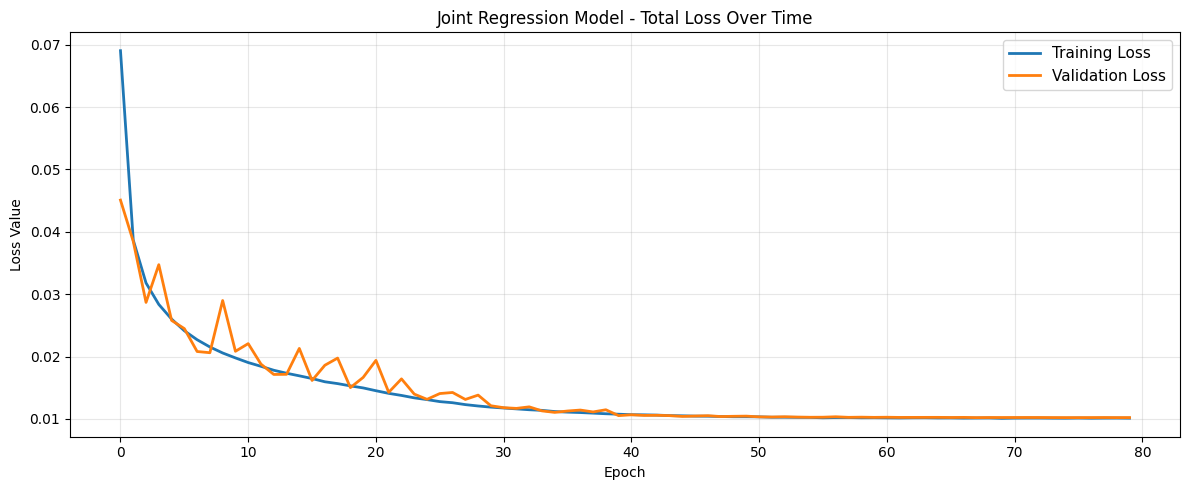

✓ Loss plot generated


In [8]:
# ====================================================================
# PLOT TRAINING HISTORY - Total Loss
# ====================================================================

import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))
plt.plot(hist_df.index, hist_df['loss'], label='Training Loss', linewidth=2)
plt.plot(hist_df.index, hist_df['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Joint Regression Model - Total Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Loss plot generated")

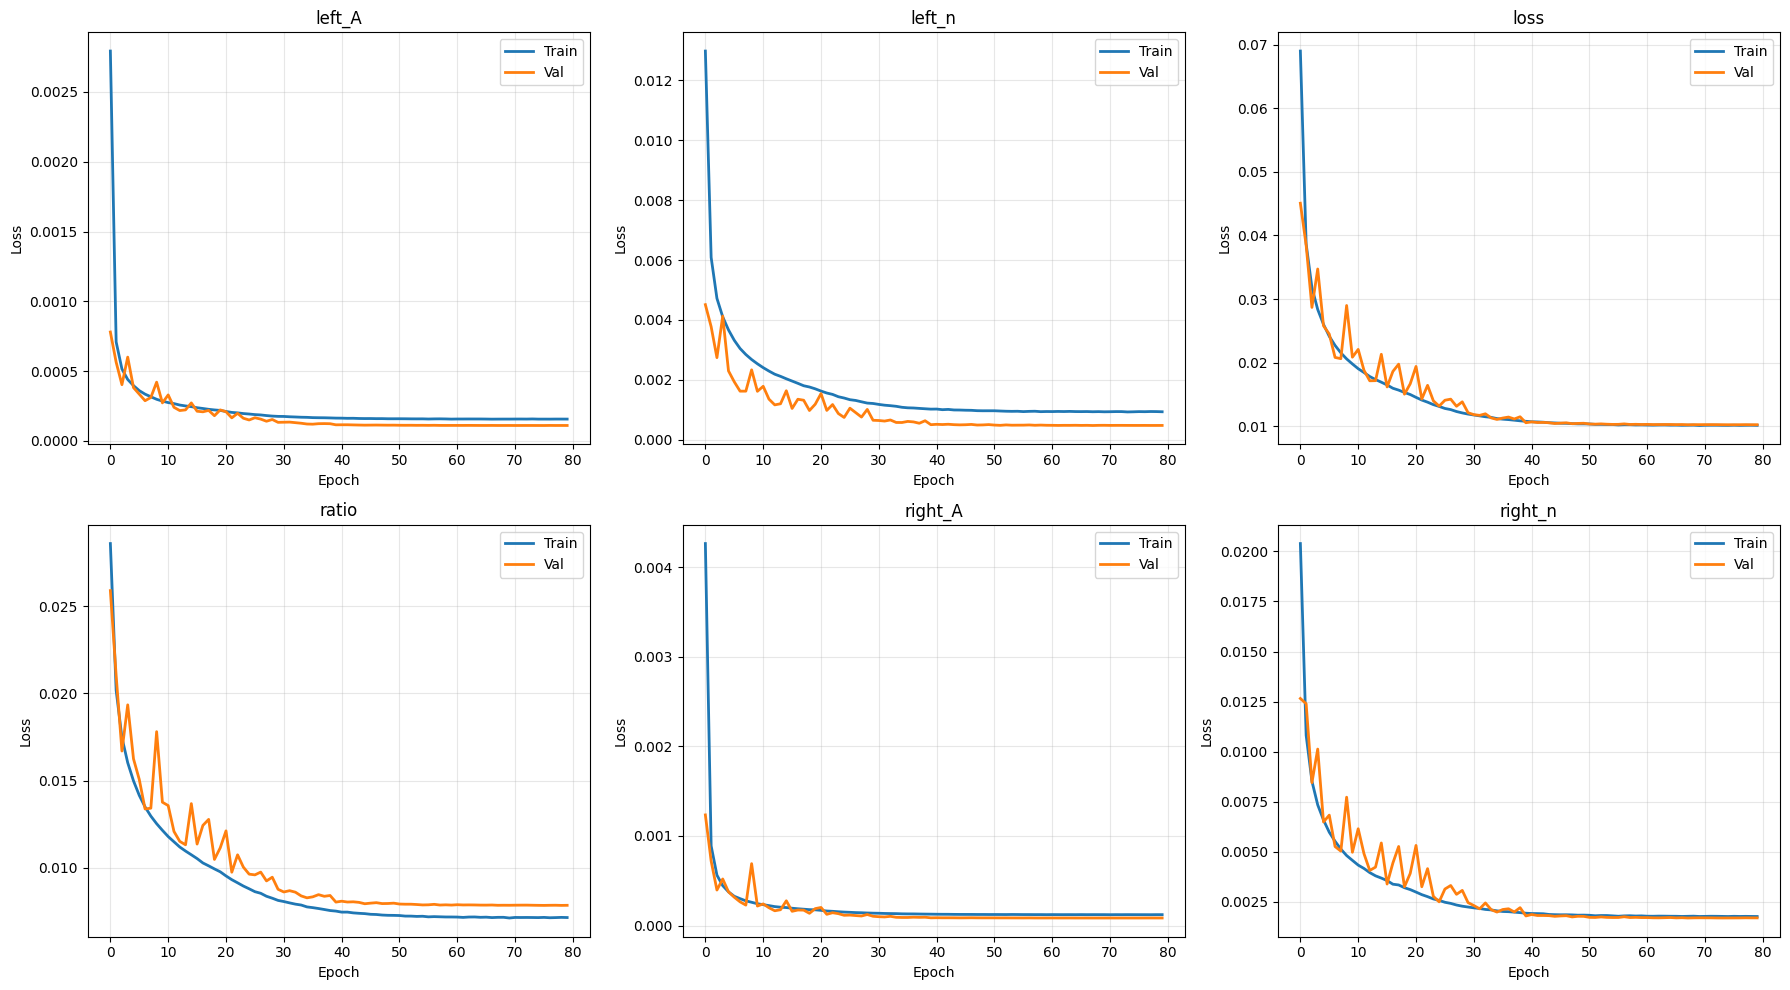

✓ Per-output loss plots generated


In [9]:
# ====================================================================
# PLOT TRAINING HISTORY - Per-Output Losses
# ====================================================================

def plot_joint_regression_history(history):
    """
    Plot training and validation loss for each output component.
    """
    present_keys = [k for k in hist_df.columns if k.endswith('loss') and not k.startswith('val')]
    
    plt.figure(figsize=(18, 10))
    
    for i, train_key in enumerate(present_keys[:6]):  # Max 6 subplots
        plt.subplot(2, 3, i + 1)
        val_key = f'val_{train_key}'
        
        if train_key in hist_df.columns:
            plt.plot(hist_df.index, hist_df[train_key], label=f'Train', linewidth=2)
        if val_key in hist_df.columns:
            plt.plot(hist_df.index, hist_df[val_key], label=f'Val', linewidth=2)
        
        plt.title(f'{train_key.replace("_output_loss", "").replace("_loss", "")}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_joint_regression_history(history)
print("✓ Per-output loss plots generated")

In [10]:
# ====================================================================
# TEST SET INFERENCE
# ====================================================================
# Make predictions on test set and visualize results

print("Making predictions on test set...")

test_predictions = joint_regression_model.predict(
    [X_test, 
     to_categorical(y_left_test, num_classes=r),
     to_categorical(y_right_test, num_classes=r)],
    verbose=1
)

# Unpack predictions
test_ratio_pred = test_predictions[0].flatten()
test_left_A_pred = test_predictions[1].flatten()
test_left_n_pred = test_predictions[2].flatten()
test_right_A_pred = test_predictions[3].flatten()
test_right_n_pred = test_predictions[4].flatten()

# Unpack ground truth
test_ratio_true = y_test[:, 2].copy()
test_left_A_true = y_test[:, 4].copy()
test_left_n_true = y_test[:, 1].copy()
test_right_A_true = y_test[:, 3].copy()
test_right_n_true = y_test[:, 0].copy()

print("✓ Test predictions generated")

Making predictions on test set...
9075/9075 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
✓ Test predictions generated


/tmp/ipykernel_19/4018055643.py:134: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


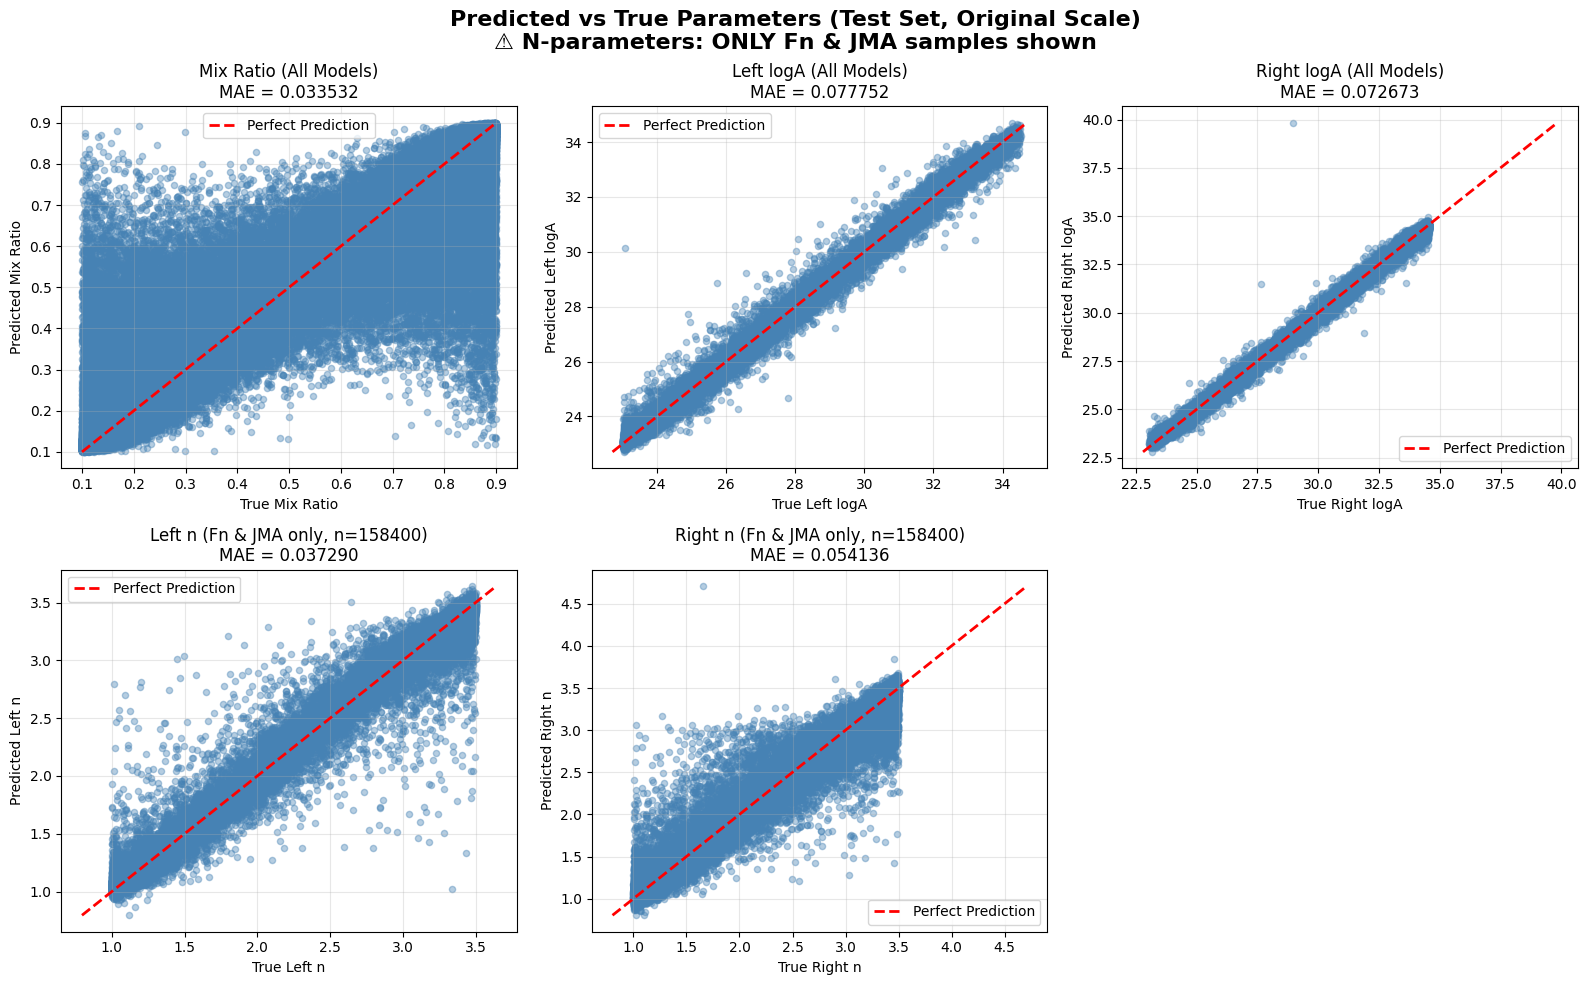


TEST SET PERFORMANCE SUMMARY (MODEL-AWARE)

All Models:
  Mix Ratio MAE:  0.033532
  Left logA MAE:  0.077752
  Right logA MAE: 0.072673

Fn & JMA Models Only (using n parameter):
  Left n count:   158400 samples
  Left n MAE:     0.037290
  Right n count:  158400 samples
  Right n MAE:    0.054136

Other Models (D2, D3, D4, R2, R3 - should not use n):
  Left non-n count:  132000 samples
  Right non-n count: 132000 samples


In [11]:
# ====================================================================
# JOINT PLOT: Predicted vs True for All Parameters (Test Set, Original Scale)
# MODEL-AWARE FILTERING FOR N-PARAMETERS
# ====================================================================

# Get normalization parameters (correct ranges)
logA_range = params['logA_range']
n_range = params['n_range']
mix_range = params['mix_range']

# Denormalize predictions and true values
# Mix/Ratio uses mix_range
test_ratio_true_denorm = test_ratio_true * (mix_range[1] - mix_range[0]) + mix_range[0]
test_ratio_pred_denorm = test_ratio_pred * (mix_range[1] - mix_range[0]) + mix_range[0]

# Left A and Right A use logA_range
test_left_A_true_denorm = test_left_A_true * (logA_range[1] - logA_range[0]) + logA_range[0]
test_left_A_pred_denorm = test_left_A_pred * (logA_range[1] - logA_range[0]) + logA_range[0]

test_right_A_true_denorm = test_right_A_true * (logA_range[1] - logA_range[0]) + logA_range[0]
test_right_A_pred_denorm = test_right_A_pred * (logA_range[1] - logA_range[0]) + logA_range[0]

# Left n and Right n use n_range
test_left_n_true_denorm = test_left_n_true * (n_range[1] - n_range[0]) + n_range[0]
test_left_n_pred_denorm = test_left_n_pred * (n_range[1] - n_range[0]) + n_range[0]

test_right_n_true_denorm = test_right_n_true * (n_range[1] - n_range[0]) + n_range[0]
test_right_n_pred_denorm = test_right_n_pred * (n_range[1] - n_range[0]) + n_range[0]

# ===== CRITICAL: Filter n-parameters by model type =====
# Only Fn (3) and JMA (4) use the n parameter
# Models that don't use n: D2(0), D3(1), D4(2), R2(5), R3(6)
N_USING_MODELS = set([3, 4])  # Fn=3, JMA=4
MODEL_NAMES = ['D2', 'D3', 'D4', 'Fn', 'JMA', 'R2', 'R3']

# Create masks for n-using models
left_uses_n = np.isin(y_left_test, list(N_USING_MODELS))
right_uses_n = np.isin(y_right_test, list(N_USING_MODELS))

# Filter n-predictions to only include valid samples
test_left_n_true_denorm_valid = test_left_n_true_denorm[left_uses_n]
test_left_n_pred_denorm_valid = test_left_n_pred_denorm[left_uses_n]

test_right_n_true_denorm_valid = test_right_n_true_denorm[right_uses_n]
test_right_n_pred_denorm_valid = test_right_n_pred_denorm[right_uses_n]

# Create tiled plot
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Predicted vs True Parameters (Test Set, Original Scale)\n⚠ N-parameters: ONLY Fn & JMA samples shown', 
             fontsize=16, fontweight='bold')

# Color and transparency settings
alpha = 0.4
color = 'steelblue'

# ========== RATIO (Mix) - ALL SAMPLES ==========
ax = axes[0, 0]
ax.scatter(test_ratio_true_denorm, test_ratio_pred_denorm, alpha=alpha, s=20, color=color)
min_val = min(test_ratio_true_denorm.min(), test_ratio_pred_denorm.min())
max_val = max(test_ratio_true_denorm.max(), test_ratio_pred_denorm.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
mae = np.mean(np.abs(test_ratio_pred_denorm - test_ratio_true_denorm))
ax.set_xlabel('True Mix Ratio')
ax.set_ylabel('Predicted Mix Ratio')
ax.set_title(f'Mix Ratio (All Models)\nMAE = {mae:.6f}')
ax.legend()
ax.grid(True, alpha=0.3)

# ========== LEFT A (logA) - ALL SAMPLES ==========
ax = axes[0, 1]
ax.scatter(test_left_A_true_denorm, test_left_A_pred_denorm, alpha=alpha, s=20, color=color)
min_val = min(test_left_A_true_denorm.min(), test_left_A_pred_denorm.min())
max_val = max(test_left_A_true_denorm.max(), test_left_A_pred_denorm.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
mae = np.mean(np.abs(test_left_A_pred_denorm - test_left_A_true_denorm))
ax.set_xlabel('True Left logA')
ax.set_ylabel('Predicted Left logA')
ax.set_title(f'Left logA (All Models)\nMAE = {mae:.6f}')
ax.legend()
ax.grid(True, alpha=0.3)

# ========== RIGHT A (logA) - ALL SAMPLES ==========
ax = axes[0, 2]
ax.scatter(test_right_A_true_denorm, test_right_A_pred_denorm, alpha=alpha, s=20, color=color)
min_val = min(test_right_A_true_denorm.min(), test_right_A_pred_denorm.min())
max_val = max(test_right_A_true_denorm.max(), test_right_A_pred_denorm.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
mae = np.mean(np.abs(test_right_A_pred_denorm - test_right_A_true_denorm))
ax.set_xlabel('True Right logA')
ax.set_ylabel('Predicted Right logA')
ax.set_title(f'Right logA (All Models)\nMAE = {mae:.6f}')
ax.legend()
ax.grid(True, alpha=0.3)

# ========== LEFT N - ONLY Fn & JMA SAMPLES ==========
ax = axes[1, 0]
if len(test_left_n_true_denorm_valid) > 0:
    ax.scatter(test_left_n_true_denorm_valid, test_left_n_pred_denorm_valid, alpha=alpha, s=20, color=color)
    min_val = min(test_left_n_true_denorm_valid.min(), test_left_n_pred_denorm_valid.min())
    max_val = max(test_left_n_true_denorm_valid.max(), test_left_n_pred_denorm_valid.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    mae = np.mean(np.abs(test_left_n_pred_denorm_valid - test_left_n_true_denorm_valid))
    count = len(test_left_n_true_denorm_valid)
    ax.set_xlabel('True Left n')
    ax.set_ylabel('Predicted Left n')
    ax.set_title(f'Left n (Fn & JMA only, n={count})\nMAE = {mae:.6f}')
else:
    ax.text(0.5, 0.5, 'No Fn/JMA samples', ha='center', va='center')
    ax.set_title('Left n (Fn & JMA only)\nNo samples available')
ax.legend()
ax.grid(True, alpha=0.3)

# ========== RIGHT N - ONLY Fn & JMA SAMPLES ==========
ax = axes[1, 1]
if len(test_right_n_true_denorm_valid) > 0:
    ax.scatter(test_right_n_true_denorm_valid, test_right_n_pred_denorm_valid, alpha=alpha, s=20, color=color)
    min_val = min(test_right_n_true_denorm_valid.min(), test_right_n_pred_denorm_valid.min())
    max_val = max(test_right_n_true_denorm_valid.max(), test_right_n_pred_denorm_valid.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    mae = np.mean(np.abs(test_right_n_pred_denorm_valid - test_right_n_true_denorm_valid))
    count = len(test_right_n_true_denorm_valid)
    ax.set_xlabel('True Right n')
    ax.set_ylabel('Predicted Right n')
    ax.set_title(f'Right n (Fn & JMA only, n={count})\nMAE = {mae:.6f}')
else:
    ax.text(0.5, 0.5, 'No Fn/JMA samples', ha='center', va='center')
    ax.set_title('Right n (Fn & JMA only)\nNo samples available')
ax.legend()
ax.grid(True, alpha=0.3)

# Hide the 6th subplot (not needed)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("TEST SET PERFORMANCE SUMMARY (MODEL-AWARE)")
print("=" * 80)

print(f"\nAll Models:")
print(f"  Mix Ratio MAE:  {np.mean(np.abs(test_ratio_pred_denorm - test_ratio_true_denorm)):.6f}")
print(f"  Left logA MAE:  {np.mean(np.abs(test_left_A_pred_denorm - test_left_A_true_denorm)):.6f}")
print(f"  Right logA MAE: {np.mean(np.abs(test_right_A_pred_denorm - test_right_A_true_denorm)):.6f}")

print(f"\nFn & JMA Models Only (using n parameter):")
print(f"  Left n count:   {len(test_left_n_true_denorm_valid)} samples")
if len(test_left_n_true_denorm_valid) > 0:
    mae_left_n = np.mean(np.abs(test_left_n_pred_denorm_valid - test_left_n_true_denorm_valid))
    print(f"  Left n MAE:     {mae_left_n:.6f}")
print(f"  Right n count:  {len(test_right_n_true_denorm_valid)} samples")
if len(test_right_n_true_denorm_valid) > 0:
    mae_right_n = np.mean(np.abs(test_right_n_pred_denorm_valid - test_right_n_true_denorm_valid))
    print(f"  Right n MAE:    {mae_right_n:.6f}")

print("\nOther Models (D2, D3, D4, R2, R3 - should not use n):")
left_no_n = ~left_uses_n
right_no_n = ~right_uses_n
print(f"  Left non-n count:  {left_no_n.sum()} samples")
print(f"  Right non-n count: {right_no_n.sum()} samples")

print("=" * 80)


In [12]:
# ====================================================================
# SAVE TRAINED MODEL
# ====================================================================
# Save model with custom loss function for later inference

from tensorflow.keras.models import save_model
import os

REGRESSION_MODEL_PATH = '/kaggle/working/joint_regression_model.h5'

save_model(joint_regression_model, REGRESSION_MODEL_PATH)

print(f"✓ Regression model saved to: {REGRESSION_MODEL_PATH}")
print(f"  File size: {os.path.getsize(REGRESSION_MODEL_PATH) / 1024 / 1024:.2f} MB")

✓ Regression model saved to: /kaggle/working/joint_regression_model.h5
  File size: 29.68 MB
